In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import numpy as np

train_data = np.load('/content/drive/MyDrive/DNN_Dataset/Sequence_files/sequences_train.npy')

val_data = np.load('/content/drive/MyDrive/DNN_Dataset/Sequence_files/sequences_val.npy')

print(train_data.shape)
print(val_data.shape)

(142119, 11, 4)
(45686, 11, 4)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os, random

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [19]:
train_data = np.load('/content/drive/MyDrive/DNN_Dataset/Sequence_files/sequences_train.npy')
val_data   = np.load('/content/drive/MyDrive/DNN_Dataset/Sequence_files/sequences_val.npy')

def normalize(data):
    data = data.copy().astype(np.float32)
    data[:, :, 0] /= 3840  # x
    data[:, :, 1] /= 2160  # y
    data[:, :, 2] /= 3840  # w
    data[:, :, 3] /= 2160  # h
    return data

train_data = normalize(train_data)
val_data   = normalize(val_data)
print(f"Max: {train_data.max():.4f}  Min: {train_data.min():.4f}")
# Max ≈ 1.0  |  Min = 0.0

X_train, Y_train = train_data[:, :10, :], train_data[:, 10, :]
X_val,   Y_val   = val_data[:, :10, :],   val_data[:, 10, :]

print(f"X_train: {X_train.shape}  →  Y_train: {Y_train.shape}")

Max: 0.9951  Min: 0.0000
X_train: (142119, 10, 4)  →  Y_train: (142119, 4)


In [20]:
class SequenceDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.Y[idx]
        if self.augment:
            x = x + torch.randn_like(x) * 0.02
            drop_prob = random.uniform(0.10, 0.15)
            for t in range(1, 10):
                if random.random() < drop_prob:
                    x[t] = x[t - 1]
        return x, y

train_dataset = SequenceDataset(X_train, Y_train, augment=True)
val_dataset   = SequenceDataset(X_val,   Y_val,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 278 | Val batches: 90


In [21]:
class GRUTracker(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 4)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUTracker().to(DEVICE)
dummy = torch.zeros(8, 10, 4).to(DEVICE)
assert model(dummy).shape == (8, 4)
print("Model output shape: ✓")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: ✓
Total parameters: 151,044


In [22]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

EPOCHS    = 50
SAVE_PATH = '/content/drive/MyDrive/DNN_Dataset/best_gru.pth'

best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(xb)
    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(val_dataset)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Epoch {epoch:3d} | train: {train_loss:.6f} | val: {val_loss:.6f}  ✓ saved")
    else:
        print(f"Epoch {epoch:3d} | train: {train_loss:.6f} | val: {val_loss:.6f}")

Epoch   1 | train: 0.003468 | val: 0.000123  ✓ saved
Epoch   2 | train: 0.000236 | val: 0.000049  ✓ saved
Epoch   3 | train: 0.000182 | val: 0.000040  ✓ saved
Epoch   4 | train: 0.000166 | val: 0.000042
Epoch   5 | train: 0.000153 | val: 0.000044
Epoch   6 | train: 0.000145 | val: 0.000033  ✓ saved
Epoch   7 | train: 0.000140 | val: 0.000042
Epoch   8 | train: 0.000136 | val: 0.000038
Epoch   9 | train: 0.000135 | val: 0.000034
Epoch  10 | train: 0.000129 | val: 0.000036
Epoch  11 | train: 0.000123 | val: 0.000030  ✓ saved
Epoch  12 | train: 0.000122 | val: 0.000031
Epoch  13 | train: 0.000122 | val: 0.000029  ✓ saved
Epoch  14 | train: 0.000121 | val: 0.000029
Epoch  15 | train: 0.000121 | val: 0.000026  ✓ saved
Epoch  16 | train: 0.000120 | val: 0.000031
Epoch  17 | train: 0.000119 | val: 0.000030
Epoch  18 | train: 0.000120 | val: 0.000027
Epoch  19 | train: 0.000119 | val: 0.000027
Epoch  20 | train: 0.000116 | val: 0.000029
Epoch  21 | train: 0.000115 | val: 0.000028
Epoch  22 | t

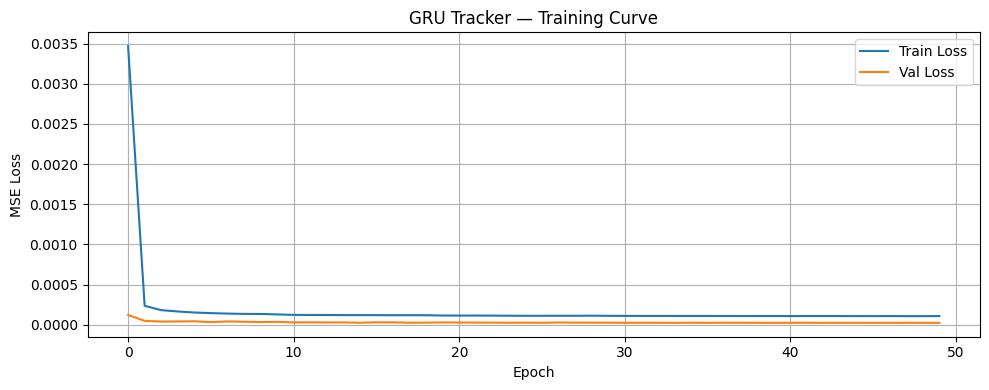

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('GRU Tracker — Training Curve')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DNN_Dataset/gru_loss_curve.png')
plt.show()

In [24]:
class GRUMotionModel:
    """
    Wrapper around the trained GRU.
    Interface: predict(history) -> [x, y, w, h]

    history: list of up to 10 [x, y, w, h] boxes  (most recent last)
    returns: predicted next-frame [x, y, w, h]  as a Python list
    """
    def __init__(self, model_path, device=None):
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model  = GRUTracker().to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()

    def predict(self, history):
        """
        history: list of [x, y, w, h]  — length 1 to 10
                 if shorter than 10, pad by repeating the first box at the start
        returns: [x, y, w, h]  as a Python list
        """
        # Pad to exactly 10 frames if shorter
        while len(history) < 10:
            history = [history[0]] + history

        seq = torch.tensor(history[-10:], dtype=torch.float32)   # (10, 4)
        seq = seq.unsqueeze(0).to(self.device)                   # (1, 10, 4)

        with torch.no_grad():
            pred = self.model(seq)                               # (1, 4)

        return pred.squeeze(0).cpu().tolist()                    # [x, y, w, h]


# Quick test
motion_model = GRUMotionModel(SAVE_PATH)

fake_history = [[0.5, 0.5, 0.1, 0.1]] * 10        # 10 identical boxes
predicted    = motion_model.predict(fake_history)
print(f"Test predict output: {predicted}")
print(f"Output length: {len(predicted)}  ← should be 4")

Test predict output: [0.5009390115737915, 0.5006467700004578, 0.09619729220867157, 0.09995897114276886]
Output length: 4  ← should be 4


GRU Total Parameters: 151,044

Validation Average IoU: 0.7108  (target from plan: > 0.65)


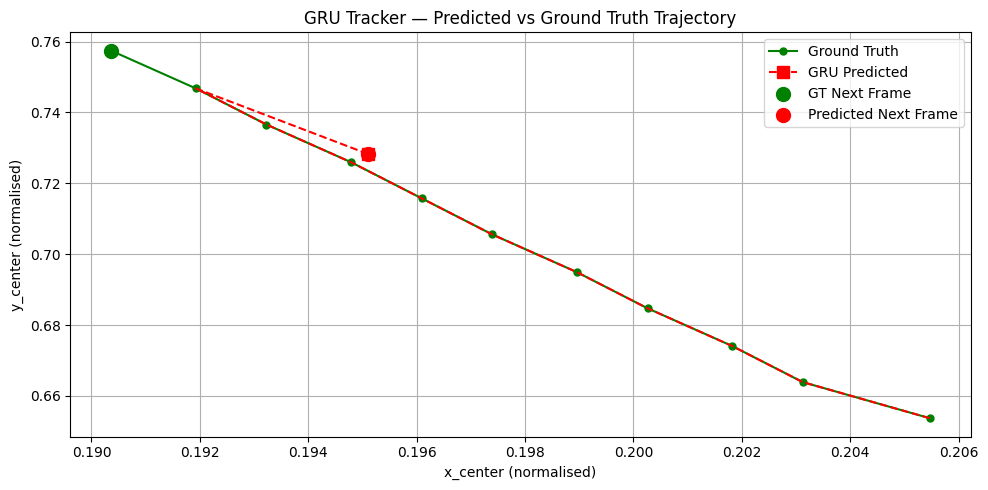


Ground Truth next box : [0.19036458432674408, 0.7574074268341064, 0.12057291716337204, 0.1111111119389534]
Predicted next box    : [0.1951, 0.7282, 0.1146, 0.1023]


In [25]:
# 1. Parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"GRU Total Parameters: {total_params:,}")

# 2. Average IoU on val set
def iou_1d(pred, target):
    """
    Box IoU for normalised [x_center, y_center, w, h].
    Converts to [x1,y1,x2,y2] format first.
    """
    def to_corners(b):
        x1 = b[..., 0] - b[..., 2] / 2
        y1 = b[..., 1] - b[..., 3] / 2
        x2 = b[..., 0] + b[..., 2] / 2
        y2 = b[..., 1] + b[..., 3] / 2
        return x1, y1, x2, y2

    px1, py1, px2, py2 = to_corners(pred)
    tx1, ty1, tx2, ty2 = to_corners(target)

    inter_x1 = torch.max(px1, tx1)
    inter_y1 = torch.max(py1, ty1)
    inter_x2 = torch.min(px2, tx2)
    inter_y2 = torch.min(py2, ty2)

    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    pred_area  = (px2 - px1) * (py2 - py1)
    tgt_area   = (tx2 - tx1) * (ty2 - ty1)
    union_area = pred_area + tgt_area - inter_area

    return (inter_area / union_area.clamp(min=1e-6)).mean().item()


model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_iou = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred   = model(xb)
        batch_iou = iou_1d(pred, yb)
        all_iou.append(batch_iou)

avg_iou = np.mean(all_iou)
print(f"\nValidation Average IoU: {avg_iou:.4f}  (target from plan: > 0.65)")

# 3. Trajectory plot on one sample
sample_seq    = val_data[0]           # (11, 4)
input_history = sample_seq[:10]       # (10, 4)  — ground truth history
gt_next       = sample_seq[10]        # (4,)

predicted_next = motion_model.predict(input_history.tolist())

plt.figure(figsize=(10, 5))
xs_gt  = [b[0] for b in input_history] + [gt_next[0]]
ys_gt  = [b[1] for b in input_history] + [gt_next[1]]
xs_pred = [b[0] for b in input_history] + [predicted_next[0]]
ys_pred = [b[1] for b in input_history] + [predicted_next[1]]

plt.plot(xs_gt,   ys_gt,   'g-o', label='Ground Truth',  markersize=5)
plt.plot(xs_pred, ys_pred, 'r--s', label='GRU Predicted', markersize=8, markevery=[-1])
plt.scatter(xs_gt[-1],    ys_gt[-1],    color='green', zorder=5, s=100, label='GT Next Frame')
plt.scatter(predicted_next[0], predicted_next[1], color='red', zorder=5, s=100, label='Predicted Next Frame')

plt.xlabel('x_center (normalised)')
plt.ylabel('y_center (normalised)')
plt.title('GRU Tracker — Predicted vs Ground Truth Trajectory')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DNN_Dataset/gru_trajectory.png')
plt.show()

print(f"\nGround Truth next box : {gt_next.tolist()}")
print(f"Predicted next box    : {[round(v,4) for v in predicted_next]}")

In [26]:

print(f"Max value in train: {train_data.max():.2f}")
print(f"Min value in train: {train_data.min():.2f}")
print(f"Sample row: {train_data[0, 0, :]}")

Max value in train: 1.00
Min value in train: 0.00
Sample row: [0.37708333 0.21527778 0.01901042 0.01157407]
